# Document Pattern Detection

This notebook demonstrates `FormulaSearch.detect_document_patterns`, which detects how a set of candidate formulaic phrases co-occur across a long text stream and groups them into communities of phrases that tend to occur together &mdash; an empirically derived signature of a document type.

This addresses a specific use case: text streams (e.g. scanned books containing hundreds of pages of resolutions, deeds, or letters) where document boundaries are not known in advance. Rather than relying on document boundaries, the pipeline scans the continuous token stream and counts how often pairs of known/candidate formulas occur within a configurable distance of each other. Phrases that habitually co-occur are connected in a weighted graph, and community detection on that graph reveals groups of phrases that signal the same recurring document type.

We'll use a small synthetic corpus with three distinct "document types", each with its own opening and closing formula, so the expected result is easy to verify.

In [1]:
%reload_ext autoreload
%autoreload 2

import random

import matplotlib.pyplot as plt
import networkx as nx

from formula_detection.search import FormulaSearch
from formula_detection.context import PhraseContext

## 1. Building a synthetic multi-document-type text stream

We generate 80 short "documents", each randomly assigned one of three types (`alpha`, `beta`, `gamma`). Every document consists of an opening formula, a stretch of random filler words, and a matching closing formula. The documents are concatenated into a single flat token stream with **no boundary markers** &mdash; exactly the situation this pipeline is designed for.

In [162]:
from pathlib import Path
from republic.helper.text_helper import ResolutionSentences

para_dir = Path('../../republic-project/data/paragraphs/entities-Mar-2026/')
para_files = list(para_dir.glob('*.tsv.gz'))
selected_files = [pf for pf in para_files if '-38' in pf.name]
documents = [doc for doc in ResolutionSentences(selected_files[:1], as_doc=True)]

print(f"number of documents: {len(documents)}")

for sent in documents:
    print(sent)
    break

number of documents: 2444
Doc(id='None', metadata={'session_date': '1783-01-02', 'resolution_id': 'session-3840-num-1-attendance_list', 'para_id': 'session-3840-num-1-para-1', 'line_start': 'NL-HaNA_1.01.02_3840_0004-line-2816-1393-175-53', 'line_end': 'NL-HaNA_1.01.02_3840_0004-line-2728-1512-356-51'}, text="1783. Zynde Nieuwejaarsdag. Nihil actum est.", tokens=['1783', '.', 'zynde', 'nieuwejaarsdag', '.', 'nihil', 'actum', 'est', '.']


## 2. Initializing FormulaSearch

`FormulaSearch` accepts any iterable of documents (here, a plain list of token lists). Because `detect_document_patterns` re-reads the corpus from the start to scan for phrase co-occurrences, the iterable needs to be restartable &mdash; a plain list already satisfies this. For very large corpora that don't fit in memory, wrap your on-disk reader in a small class with an `__iter__` method instead.

In [189]:
min_freq = 500
formula_search = FormulaSearch(documents, min_term_freq=min_freq, min_cooc_freq=min_freq)


1. Iterating over sentences to calculate term frequencies
    full collection size (tokens): 456,791
    full lexicon size (types): 18,004
    minimum term frequency: 500
    minimum frequency lexicon size: 118
2. Iterating over sentences to calculate the co-occurrence frequencies
docs: 2,444	num_words: 456,791	num_coocs: 937,122	num distinct coocs: 10,058
    co-occurrence index size: 10,058


In [190]:
common_terms = [formula_search.id2term(tid) for tid, f in formula_search.term_freq.most_common(100)]
function_words = [term for term in common_terms if len(term) < 5]
print(function_words)

[',', 'van', 'de', 'en', 'te', '.', 'den', 'het', 'in', 'dat', 'haar', 'hoog', 'op', 'aan', 'om', 'een', 'daar', 'der', 'mog', 'is', 'ter', 'uit', 'waar', 'tot', 'met', 'na', 'by', ';', 'soo', 'ten', 'die', 'sal', 'voor', 'door', 'als', 'zyn', 'of', '-', 'was', 'doen', 'niet', "'", 'sig', 'mits', 'hy', '1783', 'hun', 'hem']


In [191]:
#variant_index = formula_search.build_variant_index(function_words=function_words)
#formula_search.reindex_with_variants(variant_index)

In [192]:
import time
from collections import Counter

start = time.time()
extractor = formula_search.extract_phrases(phrase_type='sub_phrases', max_phrase_length=3,
                                                 min_cooc_freq=min_freq, max_skips=0)

# extractor = formula_search.extract_phrases(phrase_type='long_phrases',
#                                                  min_cooc_freq=min_freq)

phrase_freq = Counter([candidate_match.candidate_phrase.phrase_string for ci, candidate_match in enumerate(extractor)])
print('num phrase types:', len(phrase_freq), 'num phrase tokens', sum(phrase_freq.values()))
step = time.time()
took = step - start
print(f'took: {took: >6.2f}')


Minimum co-occurrence frequency: 500
num phrase types: 3646 num phrase tokens 86054
took:   1.85


In [193]:
phrase_freq#['ontfangen een missive']

term = 'ontfangen'
term_id = formula_search.term2id(term)
formula_search.term_freq[term_id]

687

In [194]:
from string import punctuation


def is_content_phrase(phrase):
    terms = phrase.split(' ')
    if terms[0] in punctuation or terms[-1] in punctuation:
        return False
    if terms[-1] in function_words and terms[-2] in function_words:
        # last two terms are function words
        return False
    return True
    

def filter_content_phrases(phrases):
    return [phrase for phrase in phrases if is_content_phrase(phrase)]
    
        
phrases = [phrase for phrase, _ in phrase_freq.most_common(500)]

phrases = filter_content_phrases(phrases)
print(len(phrases))
phrases

176


['waar op gedelibereert',
 'goedgevonden en verstaan',
 'op gedelibereert zynde',
 'haar hoog mogende',
 'is goedgevonden en',
 'uit te geeven',
 'van het schip',
 'de requeste van',
 'ter vergaderinge geleesen',
 'is ter vergaderinge',
 'geleesen de requeste',
 'vergaderinge geleesen de',
 'een missive van',
 'den griffier fagel',
 'mits deesen te',
 'ontfangen een missive',
 'ten behoeven van',
 'in te vullen',
 'een der engelsche',
 'der engelsche pasporten',
 'te vullen en',
 'om ten behoeven',
 'daar van gebruik',
 'in te hebben',
 'soo ras doenlyk',
 'ras doenlyk uit',
 'deesen te authoriseeren',
 'te authoriseeren den',
 'authoriseeren den griffier',
 'de provincie van',
 'den heere griffier',
 'heere griffier fagel',
 'het schip de',
 'van de heeren',
 'aan den suppliant',
 'de heeren van',
 'gelieven te authoriseeren',
 'griffier fagel gelieven',
 'fagel gelieven te',
 'van gebruik sal',
 'gebruik sal maken',
 'engelsche pasporten in',
 'de voorsz requeste',
 'het schip dat',


## 3. Defining candidate formulaic phrases

In practice these candidates would come from `extract_phrases` or from a list of known partial formulas you already have for your corpus. Here we use the six formulas we generated the corpus with, so the expected grouping is easy to check.

In [195]:
candidate_phrases = [
    'opening formula alpha', 'closing formula alpha',
    'opening formula beta', 'closing formula beta',
    'opening formula gamma', 'closing formula gamma',
]
candidate_phrases = phrases

## 4. Building a PhraseContext (optional, enables phrase clustering)

`detect_document_patterns` can also run Goal 2 (semantic clustering of phrases) when given a `PhraseContext`. 

In [196]:
# Test with a small sample of documents
docs = [doc for doc in documents]


In [197]:
phrase_context = PhraseContext(candidate_phrases, sentences=documents)
phrase_context.count_phrase_contexts()

In [198]:
{key: len(phrase_context.context_count[key]) for key in phrase_context.context_count}

{'phrase': 176, 'pre': 176, 'post': 176}

## 5. Running the pattern-detection pipeline

`detect_document_patterns` chains together:

1. **Variant detection** (Goal 1) &mdash; skipped here since we passed no `spelling_normaliser` or `function_words`.
2. **Phrase clustering** (Goal 2) &mdash; runs because we supplied `phrase_context`.
3. **Phrase co-occurrence + community detection** (Goal 3) &mdash; always runs. It flattens the corpus into one token stream, counts how often each pair of candidate phrases occurs within `cooc_windows` tokens of each other, builds a weighted graph at `community_window`, and partitions it with Louvain community detection.

Two windows are configured: a short one (15 tokens, comparable to the typical opening&ndash;closing distance within one document) used for both co-occurrence counting and community detection, and a long one (1000 tokens) for reference. `min_llr` filters out weak, spurious associations before community detection runs.

In [199]:
import cProfile
from fuzzy_search.similarity import SkipgramSimilarity

### Fuzzy-search improvements

running detect_document_patterns on paragraphs of one resolution inventory:
- original code: 25.556 seconds
- optimised code: 17.827 seconds

In [200]:
# command = """result = formula_search.detect_document_patterns(
#     candidate_phrases,
#     cooc_windows=[15, 1000],
#     community_window=15,
#     min_llr=5.0,
#     phrase_context=phrase_context,
# )"""

# cProfile.run(command)

In [201]:
# command = """result = formula_search.detect_document_patterns(
#     candidate_phrases,
#     cooc_windows=[15, 1000],
#     community_window=15,
#     min_llr=5.0,
#     phrase_context=phrase_context,
# )"""

# cProfile.run(command)

In [202]:
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.DataFrame({'length': [len(doc) for doc in documents]})
df.describe(percentiles=np.arange(0.0, 1.0, 0.1))

,length
count,2444.000000
mean,186.903028
std,267.765651
min,1.000000
0%,1.000000
10%,27.000000
20%,45.600000
30%,80.900000
40%,110.000000
50%,133.000000


In [306]:
start = time.time()
cooc_windows = [5, 1000]

result = formula_search.detect_document_patterns(
    candidate_phrases,
    cooc_windows=cooc_windows,
    community_window=min(cooc_windows),
    min_llr=1_000,
    phrase_context=phrase_context,
)

step = time.time()
took = step - start
print(f"took {took:.0f} seconds")

result.keys()

took 11 seconds


dict_keys(['variant_index', 'phrase_clusters', 'cooc_index', 'phrase_graph', 'community_map'])

#### Intermezzo - understanding the phrase co-occurrence index

In [307]:
from formula_detection.phrase_cooccurrence import PhraseCooccurrenceIndex

variant_index = formula_search.build_variant_index(phrase_context=phrase_context)

In [308]:
cooc_windows = [5, 1000]
cooc_index = PhraseCooccurrenceIndex(candidate_phrases, windows=cooc_windows)

token_stream = formula_search._flatten_doc_iterator()

cooc_index.index_stream(token_stream, variant_index=variant_index)

In [309]:
phrase1 = 'ontfangen een missive'
phrase2 = 'een missive van'
pair = (min(phrase1, phrase2), max(phrase1, phrase2))

window = 1000

print(pair)
cooc_index.phrase_positions[phrase1]
cooc_index.cooc_freq[window][pair]

('een missive van', 'ontfangen een missive')


4036

In [347]:
from itertools import combinations

len(cooc_index.cooc_freq[5])
position_phrase = {}

min_window = 5
max_window = 1000
for phrase in cooc_index.phrase_positions:
    if 'een der ' in phrase:
        print(f"phrase: {phrase}\tnum positions: {len(set(cooc_index.phrase_positions[phrase]))}")
    for pos in set(cooc_index.phrase_positions[phrase]):
        #print(pos)
        if pos in position_phrase:
            raise ValueError(f"pos {pos} already in index with phrase {position_phrase[pos]} but also for phrase {phrase}")
            
        position_phrase[pos] = phrase
    #print(f"pos: {pos} phrase: {position_phrase[pos]}")
    #break
    

phrase: een der engelsche	num positions: 539


In [352]:
bigram_freq = Counter()
trigram_freq = Counter()

positions = sorted(list(position_phrase.keys()))
for ci, curr_pos in enumerate(positions[:-1]):
    #print(f"curr_pos: {curr_pos}\tphrase: {position_phrase[curr_pos]}")
    curr_phrase = position_phrase[curr_pos]
    curr_comm = community_map[curr_phrase]
    window_phrases = []
    phrase_set = {curr_phrase}
    community_set = {curr_comm}
    for next_pos in positions[ci+1:]:
        next_phrase = position_phrase[next_pos]
        next_comm = community_map[next_phrase]
        if not min_window < next_pos - curr_pos < max_window:
            continue
        if next_phrase in phrase_set:
            break
        if next_comm in community_set:
            break
        #print(f"\tnext_pos: {next_pos}\tphrase: {position_phrase[next_pos]}")
        window_phrases.append(next_comm)
        phrase_set.add(next_phrase)
        community_set.add(next_comm)
    #print(window_phrases)
    # if curr_phrase == 'een der engelsche':
    #     print(curr_pos, curr_phrase, window_phrases)
    
    bigram_freq.update([(curr_comm, phrase2) for phrase2 in window_phrases])
    trigram_freq.update([(curr_comm, phrase2, phrase3) for phrase2, phrase3 in combinations(window_phrases, 2)])
    
    if ci + 1 >= 30000:
        break
        

In [357]:
community_phrases = defaultdict(list)
for phrase in community_map:
    community_phrases[community_map[phrase]].append(phrase)

#community_phrases

In [362]:
for comms, freq in trigram_freq.most_common(30):
    comm1, comm2, comm3 = comms
    print(freq, [community_phrases[comm1][0], community_phrases[comm2][0], community_phrases[comm3][0]])
#bigram_freq.most_common(10)
#community_map

1735 ['den suppliant soo', 'in te hebben', 'en schipper die']
918 ['engelsche pasporten in', 'den suppliant soo', 'is goedgevonden en']
769 ['de requeste van', 'amsterdam , meede', 'en schipper die']
416 ['de requeste van', 'en schipper die', 'gelieven te authoriseeren']
251 ['de requeste van', 'amsterdam , meede', 'gelieven te authoriseeren']
230 ['de requeste van', 'gelieven te authoriseeren', 'is goedgevonden en']
214 ['de heeren gedeputeerden', 'de resolutie van', 'van de heeren']
190 ['de requeste van', 'versoekende den suppliant', 'is goedgevonden en']
190 ['is goedgevonden en', 'de voorsz missive', 'in de voorsz']
181 ['de requeste van', 'mog . gelieven', 'gelieven te authoriseeren']
175 ['een missive van', 'gelieven te authoriseeren', 'maand , houdende']
169 ['is goedgevonden en', 'de voorsz missive', 'sal worden aan']
155 ['en schipper die', 'mog . gelieven', 'gelieven te authoriseeren']
145 ['is goedgevonden en', 'van de heeren', 'de heeren gedeputeerden']
141 ['is goedgevond

In [312]:
[p for p in candidate_phrases if 'missive' in p]

['een missive van',
 'ontfangen een missive',
 'de missive van',
 'de voorsz missive',
 'op een missive',
 'by missive van',
 'op de missive']

In [313]:
from collections import defaultdict

# cooc_index.llr_scores(5)
scores = cooc_index.llr_scores(5)
thresholds = [1, 10, 100, 1000, 10_000, 100_000, 1000_000]
ccdf = defaultdict(int)
for pair, score in scores.items():
    if score > 1_000:
        print(pair)
    for threshold in thresholds:
        if score < threshold:
            ccdf[threshold] += 1

#ax = sns.kdeplot(scores.values())
#ax.set_xlim(0, 20_000)
ccdf

('een missive van', 'ontfangen een missive')
('ontfangen een missive', 'van den heere')
('een missive van', 'van den heere')
('de provincie van', 'uit de provincie')
('haar hoog mogende', 'hoog mogende resolutie')
('hoog mogende resolutie', 'mogende resolutie van')
('aan den griffier', 'den griffier fagel')
('aan den griffier', 'fagel , houdende')
('den griffier fagel', 'fagel , houdende')
('het schip de', 'van het schip')
('op gedelibereert zynde', 'waar op gedelibereert')
('is goedgevonden en', 'waar op gedelibereert')
('is goedgevonden en', 'op gedelibereert zynde')
('goedgevonden en verstaan', 'op gedelibereert zynde')
('goedgevonden en verstaan', 'is goedgevonden en')
('de heeren van', 'van de heeren')
('haar hoog mogende', 'hoog mogende gedeputeerden')
('haar hoog mogende', 'mogende gedeputeerden tot')
('hoog mogende gedeputeerden', 'mogende gedeputeerden tot')
('is goedgevonden en', 'mits deesen te')
('goedgevonden en verstaan', 'mits deesen te')
('is ter vergaderinge', 'ter ver

defaultdict(int,
            {10000: 606,
             100000: 621,
             1000000: 621,
             1000: 437,
             100: 328,
             10: 189,
             1: 25})

## 6. Inspecting the results

In [314]:
cooc_index = result['cooc_index']
print('Phrase frequencies in the stream:')
for phrase, freq in cooc_index.phrase_freq.most_common():
    print(f'  {phrase: <45}{freq}')

Phrase frequencies in the stream:
  waar op gedelibereert                        1322
  goedgevonden en verstaan                     1317
  haar hoog mogende                            1297
  op gedelibereert zynde                       1278
  is goedgevonden en                           1157
  uit te geeven                                1064
  van het schip                                1026
  de requeste van                              934
  ter vergaderinge geleesen                    823
  is ter vergaderinge                          814
  vergaderinge geleesen de                     796
  geleesen de requeste                         794
  een missive van                              699
  ten behoeven van                             676
  den griffier fagel                           658
  mits deesen te                               651
  ontfangen een missive                        587
  om ten behoeven                              569
  der engelsche pasporten                

In [317]:
print('Community map (phrase -> community id):')
for phrase, community_id in sorted(result['community_map'].items(), key=lambda x: x[1]):
    # if 'missive' not in phrase:
    #     continue
    print(f'  community {community_id}: {phrase}')

Community map (phrase -> community id):
  community 0: ter admiraliteit te
  community 0: admiraliteit te amsterdam
  community 1: het schip het
  community 2: hoog mogende aan
  community 3: dat de heeren
  community 4: den suppliant in
  community 5: het schip die
  community 6: en de supplianten
  community 7: ter admiraliteit op
  community 8: hoog mogende in
  community 9: by de voorsz
  community 10: hoog mogende te
  community 11: mog . resolutie
  community 12: hoog mogende van
  community 13: hoog mogende de
  community 14: by der selver
  community 15: als meede de
  community 16: dat het schip
  community 17: de heeren gedeputeerden
  community 17: uit de provincie
  community 17: van de provincie
  community 17: hebben de heeren
  community 17: de provincie van
  community 17: zynde , hebben
  community 17: heeren gedeputeerden van
  community 18: de voorsz missive
  community 18: van de voorsz
  community 19: aan de heeren
  community 20: dat de voorsz
  community 21: mog 

In [259]:
graph = cooc_index.build_graph(5)
graph.number_of_edges()

432

Each of the three document types (`alpha`, `beta`, `gamma`) forms its own community containing exactly its opening and closing formula &mdash; recovered purely from co-occurrence statistics in the flat token stream, with no document boundaries ever supplied to the pipeline.

## 7. Visualising the phrase co-occurrence graph

Nodes are candidate phrases; edge weights are log-likelihood-ratio (LLR) association scores. Node colour encodes the community assignment, so phrases that signal the same document type are visually grouped together.

/var/folders/xk/pp9n20396sqccydf42gn2rmr0000gn/T/ipykernel_55239/1035897872.py:32: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


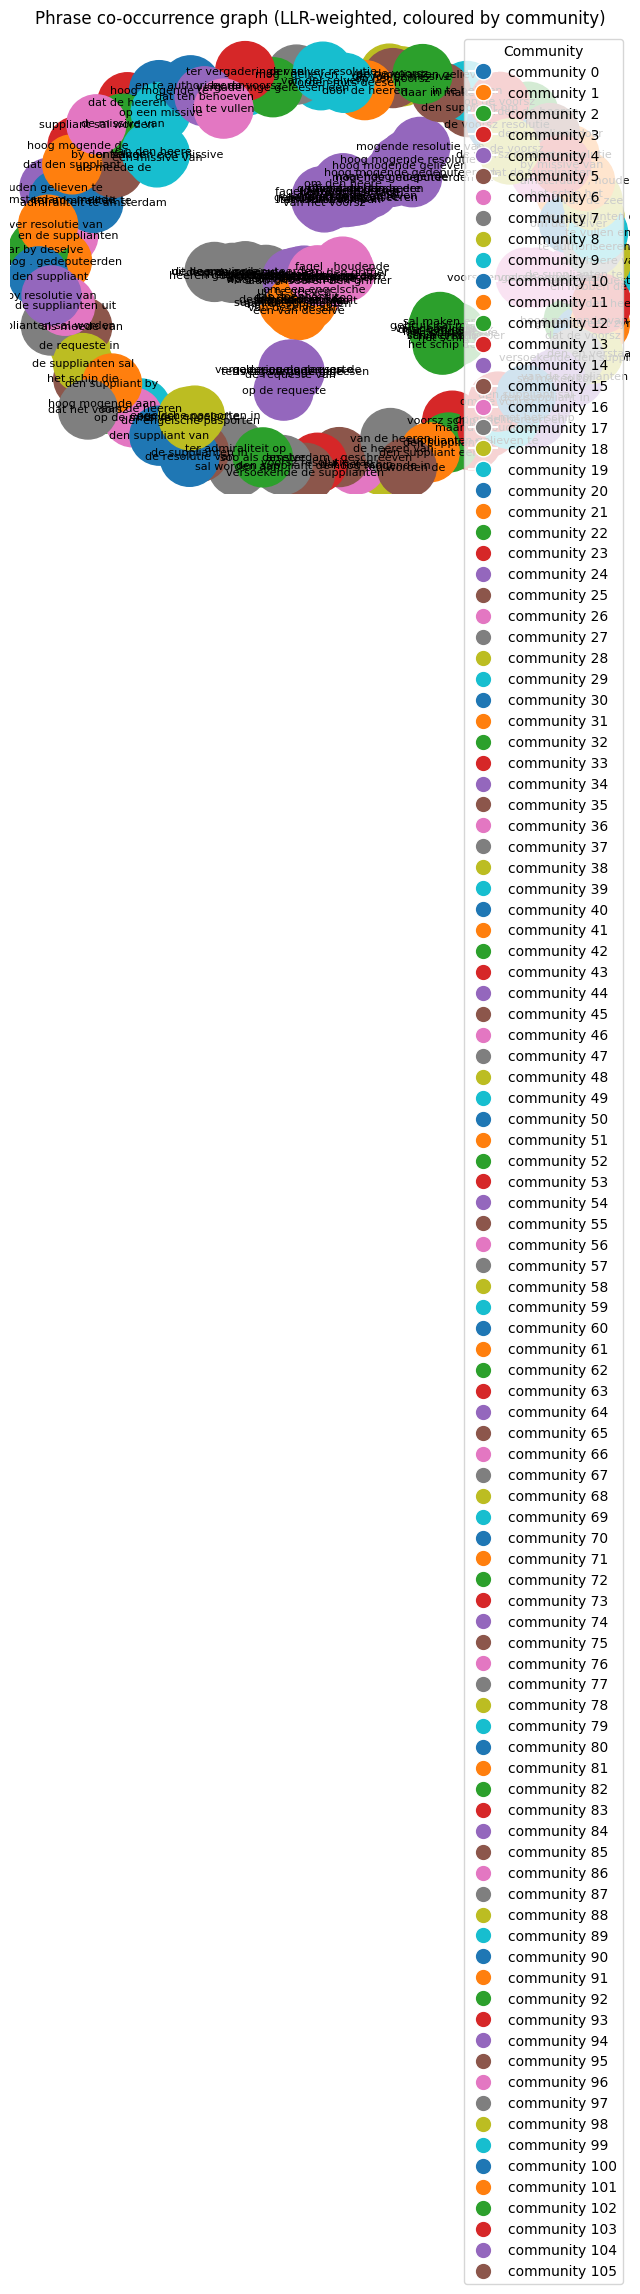

In [318]:
graph = result['phrase_graph']
community_map = result['community_map']

fig, ax = plt.subplots(figsize=(8, 6))

pos = nx.spring_layout(graph, seed=42, k=1.2)

communities = sorted(set(community_map.values()))
cmap = plt.get_cmap('tab10')
community_colors = {c: cmap(i % 10) for i, c in enumerate(communities)}
node_colors = [community_colors[community_map[n]] for n in graph.nodes()]

weights = [graph[u][v]['weight'] for u, v in graph.edges()]
max_weight = max(weights) if weights else 1.0
edge_widths = [1 + 4 * (w / max_weight) for w in weights]

nx.draw_networkx_edges(graph, pos, width=edge_widths, alpha=0.4, ax=ax)
nx.draw_networkx_nodes(graph, pos, node_color=node_colors, node_size=1800, ax=ax)
nx.draw_networkx_labels(graph, pos, font_size=8, ax=ax)

edge_labels = {(u, v): f"{graph[u][v]['weight']:.0f}" for u, v in graph.edges()}
nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_size=7, ax=ax)

legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=community_colors[c],
               markersize=12, label=f'community {c}')
    for c in communities
]
ax.legend(handles=legend_handles, loc='upper right', title='Community')
ax.set_title('Phrase co-occurrence graph (LLR-weighted, coloured by community)')
ax.axis('off')
plt.tight_layout()
plt.show()

## 8. Comparing to phrase clusters (Goal 2)

Since we also supplied `phrase_context`, `detect_document_patterns` ran semantic clustering on the same phrases based on their surrounding context words. With this corpus there's not enough distinct context vocabulary to fully separate clusters as cleanly as the co-occurrence communities, but the result is available for inspection and grows more informative with richer, larger corpora.

In [261]:
phrase_clusters = result['phrase_clusters']
if phrase_clusters is not None:
    print(phrase_clusters)
    for cluster_id in sorted(phrase_clusters.cluster_to_phrases):
        print(f'  cluster {cluster_id}: {phrase_clusters.phrases_in(cluster_id)}')
else:
    print('No phrase_clusters produced (e.g. no context vocabulary found).')

PhraseClusters(n_clusters=164, n_phrases=176)
  cluster 0: ['voorsz engelsche pasporten', 'de voorsz engelsche']
  cluster 1: ['suppliant soo ras', 'supplianten soo ras']
  cluster 2: ['de supplianten om', 'den suppliant om']
  cluster 3: ['van gebruik sal', 'gebruik sal maken']
  cluster 4: ['het schip dat', 'het schip die']
  cluster 5: ['by missive van']
  cluster 6: ['den suppliant soo', 'de supplianten soo']
  cluster 7: ['de supplianten uit']
  cluster 8: ['mog . gedeputeerden', 'hoog mogende gedeputeerden']
  cluster 9: ['het schip de', 'het schip het']
  cluster 10: ['voorsz schip de', 'voorsz schip het']
  cluster 11: ['den en verstaan']
  cluster 12: ['souden gelieven te']
  cluster 13: ['by de voorsz']
  cluster 14: ['daar in maken']
  cluster 15: ['suppliant sal worden']
  cluster 16: ['worden de heeren']
  cluster 17: ['mog . gelieven', 'hoog mogende gelieven']
  cluster 18: ['aan den suppliant', 'aan de supplianten']
  cluster 19: ['aan den heere']
  cluster 20: ['op de m

## Next steps

* For a real corpus, replace `candidate_phrases` with output from `FormulaSearch.extract_phrases` or with your own curated list of known partial formulas.
* Pass `function_words` and/or `spelling_normaliser` to `detect_document_patterns` to enable orthographic variant detection (Goal 1) before clustering and co-occurrence counting, so that spelling variants of the same formula are merged.
* `formula_detection.boundary.BoundaryDetector` builds on the `community_map` and `cooc_index` produced here to score likely document boundaries in the stream. It works best when communities correspond to a document-wide *role* (e.g. "tends to open documents" vs. "tends to close documents") rather than to document *type* as in this toy example &mdash; on a real corpus with a consistent document structure this distinction usually emerges naturally.